# Import packages

In [3]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets
# %pip install tqdm

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sodapy import Socrata
import requests

import tqdm
import json
import os
import shapely
import folium

env = os.environ

# Getting the data

In [5]:
# Settings
api_key = env.get("API_KEY")
app_token = env.get("APP_TOKEN")
secret_key = env.get("SECRET_KEY")

DATASET_ID = "kufs-yh3x"  # for 2025 # for 2024 "58t6-89vi"
limit = 100000
offset = 0

Filter = 'Manhattan'
client = Socrata("data.ny.gov", app_token = app_token)


## Getting Bus Speed Data

In [6]:
# getting the data with api call
# all_results = []

# while True:
#     batch = client.get(
#         DATASET_ID,
#         where = "Borough = 'Manhattan'",
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit

# data_df = pd.DataFrame(all_results)

## saving the data
# data_df.to_csv("Manhattan_Bus_data_23-24.csv")

# loading the data
data_df = pd.read_csv("Manhattan_Bus_data.csv", index_col = 0)

## Getting GEOJSON Data for Zip Codes

In [7]:
DATASET_ID = "pri4-ifjk"
limit = 10
offset = 0

In [8]:
all_results = []

## Getting the data
# while True:
#     batch = client.get(
#         DATASET_ID,
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit


## Converting the results into features
# features = []

# for record in all_results:
#     feature = {
#         "type": "Feature",
#         "geometry": record["the_geom"],
#         "properties": {k: v for k, v in record.items() if k != "the_geom" and k != "zcta" and k != "label"}
#     }
#     features.append(feature)


# Create GeoDataFrame
# gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
# gdf.to_file("geo_data_converted.geojson", driver="GeoJSON")

# loading the data
gdf = gpd.read_file("geo_data_converted.geojson")

## Creating point data

### Matching points to Zip codes

In [ ]:
# # Creating dataframe of points (keep original index)
# points_df = data_df[["timepoint_stop_latitude", "timepoint_stop_longitude"]].copy()

# # Ensure numeric
# points_df["timepoint_stop_latitude"] = pd.to_numeric(points_df["timepoint_stop_latitude"], errors='coerce')
# points_df["timepoint_stop_longitude"] = pd.to_numeric(points_df["timepoint_stop_longitude"], errors='coerce')


# # Create geometry (lon, lat order for Point)
# points_df["geometry"] = [
#     shapely.geometry.Point(lon, lat) 
#     for lon, lat in zip(points_df["timepoint_stop_longitude"], points_df["timepoint_stop_latitude"])
# ]

# # Convert to GeoDataFrame
# gdf_points = gpd.GeoDataFrame(points_df, geometry='geometry', crs='EPSG:4326')

# # Spatial join: find which ZIP polygon each point falls within
# joined = gpd.sjoin(gdf_points, gdf[['modzcta', 'geometry']], how='left', predicate='within')

# # Add ZIP code back to original data_df using the preserved index
# data_df['zip_code'] = None  # initialize column
# data_df.loc[joined.index, 'zip_code'] = joined['modzcta'].values

In [10]:
# def _make_linestring(row):
#     lat1 = row.get("timepoint_stop_latitude")
#     lon1 = row.get("timepoint_stop_longitude")
#     lat2 = row.get("next_timepoint_stop_latitude")
#     lon2 = row.get("next_timepoint_stop_longitude")
    
#     return shapely.geometry.LineString([(lon1, lat1), (lon2, lat2)])

# # Making points to LineStrings
# data_df["LineString"] = data_df.apply(_make_linestring, axis=1)

## Loading Stop Data

In [11]:
stop_data = pd.read_csv("manhattan_stops_flat.csv")

# Cleaning the data

## Cleaning Bus Speed Data

In [12]:
# chaging timestamp to datetime and making it the index - so I can filter later
data_df["timestamp"] = pd.to_datetime(data_df["timestamp"])
data_df.set_index("timestamp", inplace = True)

# add a direction column (0 and 1) (N, S = 0 and E, W = 1) - to match it with stop data
data_df["direction_id"] = data_df["direction"].apply(lambda x: 0 if x == "N" or x == "E" else 1)

## Cleaning Stops data

In [13]:
# extracting the same route name
stop_data["route_id_new"] = stop_data["route_id"].apply(lambda x: x[x.find("_") +1:])

# adding 1 to stop order to match with speed data
stop_data["stop_order_new"] = stop_data["stop_order"] + 1

# Analyzing the data

In [14]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1615720 entries, 2023-03-01 05:00:00 to 2024-11-01 06:00:00
Data columns (total 25 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   year                              1615720 non-null  int64  
 1   month                             1615720 non-null  int64  
 2   day_of_week                       1615720 non-null  object 
 3   hour_of_day                       1615720 non-null  int64  
 4   route_id                          1615720 non-null  object 
 5   direction                         1615720 non-null  object 
 6   borough                           1615720 non-null  object 
 7   route_type                        1615720 non-null  object 
 8   stop_order                        1615720 non-null  int64  
 9   timepoint_stop_id                 1615720 non-null  int64  
 10  timepoint_stop_name               1615720 non-null  object 
 11  time

## Plotting the data

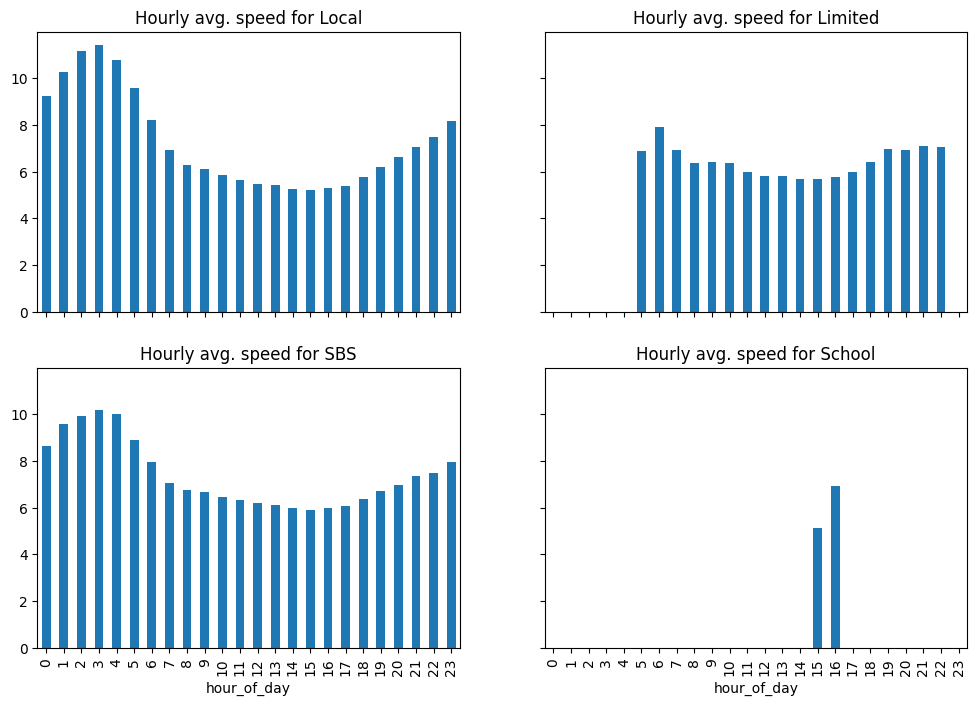

In [15]:
figs, axes = plt.subplots(2,2, figsize = (12,8), sharex = True, sharey = True)

options = list(data_df["route_type"].unique())
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    condition = options[i]
    subset = data_df[data_df["route_type"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


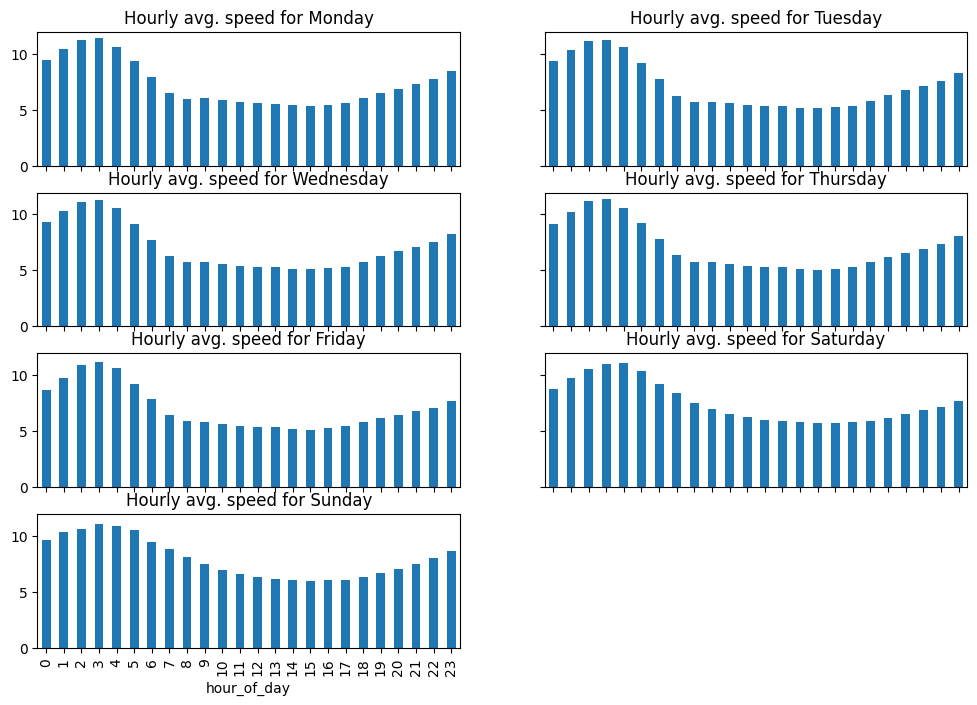

In [16]:
figs, axes = plt.subplots(4,2, figsize = (12,8), sharex = True, sharey = True)

options = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i > len(condition):
        ax.set_visible(False)
        break
    condition = options[i]
    subset = data_df[data_df["day_of_week"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


# Plotting data on map

In [17]:
# The number of stops fluctuates between the months 
## why is that?
test = data_df[(data_df["route_id"] == "M4") & (data_df["month"] == 4)].sort_values(by = ["hour_of_day", "stop_order"])

test["stop_order"].sort_values().unique()

array([ 1,  3, 10, 14, 24, 25, 28, 29, 33, 41, 45, 46, 47, 48, 49, 50, 51,
       55, 56, 60, 66, 67, 71, 77, 78])

## Plotting lines

In [18]:
from folium.plugins import MarkerCluster

def plot_bus_routes(data_df, month=None, weekday=None, route_id=None, hour = None, marker = None):
    """
    Plot NYC bus routes with color indicating average speed.
    """

    # ---- Filter data ----
    df = data_df.copy()
    if month is not None:
        df = df[df["month"] == month]
    if weekday is not None:
        df = df[df["day_of_week"] == weekday]
    if route_id is not None:
        df = df[df["route_id"] == route_id]
    if hour is not None:
        df = df[df["hour_of_day"] == hour]

    # ---- Create colors ----
    routes = sorted(df['route_id'].dropna().unique())
    cmap = plt.get_cmap('Paired', len(routes))    
    route_colors = {r: mcolors.to_hex(cmap(i)) for i, r in enumerate(routes)}

    # ---- Compute speed range ----
    speeds = df["average_road_speed"].dropna()
    min_s, max_s = speeds.min(), speeds.max()
    norm = mcolors.Normalize(vmin=min_s, vmax=max_s)
    cmap = plt.get_cmap("RdYlGn")

    # ---- Initialize map ----
    m = folium.Map(location=[40.7831, -73.9712], zoom_start=12, tiles="CartoDB positron")
    marker_cluster = MarkerCluster(name="Stops", disableClusteringAtZoom=10, maxClusterRadius=60).add_to(m)

    # ---- Plot routes ----
    for _, row in df.iterrows():
        speed = row["average_road_speed"]
        
        # Getting the coordinates
        lat1 = row.get("timepoint_stop_latitude")
        lon1 = row.get("timepoint_stop_longitude")
        lat2 = row.get("next_timepoint_stop_latitude")
        lon2 = row.get("next_timepoint_stop_longitude")
        
        line_coords = [[lat1, lon1], [lat2, lon2]]

        color = mcolors.to_hex(cmap(norm(speed)))
        color_route = route_colors.get(row["route_id"])
        
        # creating stop names for markers in loop
        stop_names = [row["timepoint_stop_name"], row["next_timepoint_stop_name"]]

        # ---- add markers if toggled to True ----
        if marker is not None and marker:
            for i in range(2):
                folium.CircleMarker(
                    location = line_coords[i],
                    radius = 7,
                    color= color_route,
                    fill_color = color_route,
                    fill = True,
                    popup=f"Route: {row['route_id']} \n Stop: {stop_names[i]}",
                ).add_to(marker_cluster)

        folium.PolyLine(
            locations = line_coords,
            color = color,
            weight = 3,
            opacity = 0.8,
            popup = f"{row['route_id']} | {speed:.1f} mph"
        ).add_to(m)

    return m


# Examples:
# Plot specific route M4 for January on Monday
m = plot_bus_routes(data_df, month=1, weekday="Tuesday", hour = 16, marker = False)
m

In [19]:
# Save map to HTML file to view in browser (workaround for trust issues)
if m is not None:
    m.save("bus_routes_map.html")
    print("Map saved to bus_routes_map.html")
    print("Open this file in your browser to view the map")


Map saved to bus_routes_map.html
Open this file in your browser to view the map


## Heatmap by Zip Code

In [20]:
# def plot_zip_heatmap(data_df, gdf_zip, metric="average_road_speed", agg_func="mean", 
#                      month=None, weekday=None, hour=None):
#     """
#     Create a choropleth heatmap showing aggregated bus data by zip code.
    
#     Parameters:
#     - data_df: DataFrame with bus data including 'zip_code' column
#     - gdf_zip: GeoDataFrame with zip code polygons (modzcta column)
#     - metric: Column to aggregate (e.g., 'average_road_speed')
#     - agg_func: Aggregation function ('mean', 'median', 'count', 'min', 'max')
#     - month, weekday, hour: Optional filters
#     """
    
#     # Filter data
#     df = data_df.copy()
#     if month is not None:
#         df = df[df["month"] == month]
#     if weekday is not None:
#         df = df[df["day_of_week"] == weekday]
#     if hour is not None:
#         df = df[df["hour_of_day"] == hour]
    
#     # Aggregate data by zip code
#     if agg_func == "mean":
#         zip_stats = df.groupby("zip_code")[metric].mean().reset_index()
#     elif agg_func == "median":
#         zip_stats = df.groupby("zip_code")[metric].median().reset_index()
#     elif agg_func == "count":
#         zip_stats = df.groupby("zip_code")[metric].count().reset_index()
#     elif agg_func == "min":
#         zip_stats = df.groupby("zip_code")[metric].min().reset_index()
#     elif agg_func == "max":
#         zip_stats = df.groupby("zip_code")[metric].max().reset_index()
    
#     zip_stats.columns = ["modzcta", "value"]
    
#     # Merge with geodataframe
#     gdf_merged = gdf_zip.merge(zip_stats, on="modzcta", how="left")
    
#     # Create map
#     m = folium.Map(location=[40.7831, -73.9712], zoom_start=11, tiles="CartoDB positron")
    
#     # Add choropleth layer
#     folium.Choropleth(
#         geo_data=gdf_merged,
#         data=gdf_merged,
#         columns=["modzcta", "value"],
#         key_on="feature.properties.modzcta",
#         fill_color="RdYlGn", 
#         fill_opacity=0.7,
#         line_opacity=0.2,
#         legend_name=f"{metric} ({agg_func})",
#         nan_fill_color="lightgray"
#     ).add_to(m)
    
#     # Add tooltips with zip code info
#     folium.GeoJson(
#         gdf_merged,
#         style_function=lambda x: {
#             'fillColor': 'transparent',
#             'color': 'transparent',
#             'weight': 0
#         },
#         tooltip=folium.GeoJsonTooltip(
#             fields=['modzcta', 'value'],
#             aliases=['Zip Code:', f'{metric} ({agg_func}):'],
#             localize=True
#         )
#     ).add_to(m)
    
#     return m

# # Example: Average speed by zip code for Tuesday at 4 PM in January
# m_heatmap = plot_zip_heatmap(
#     data_df, 
#     gdf, 
#     metric="average_road_speed",
#     agg_func="mean",
#     month=1,
#     weekday="Tuesday",
#     hour=22
# )
# m_heatmap

In [21]:
# # Save heatmap to HTML
# if m_heatmap is not None:
#     m_heatmap.save("bus_heatmap_by_zipcode.html")
#     print("Heatmap saved to bus_heatmap_by_zipcode.html")
    
# # Display using IFrame
# from IPython.display import IFrame
# display(IFrame(src='bus_heatmap_by_zipcode.html', width=800, height=600))

# Test

In [22]:
data_df["average_road_speed"].describe()

count    1.615720e+06
mean     6.877773e+00
std      2.658544e+00
min      1.709576e-01
25%      5.115874e+00
50%      6.226518e+00
75%      8.028046e+00
max      3.995527e+01
Name: average_road_speed, dtype: float64

<Axes: xlabel='month'>

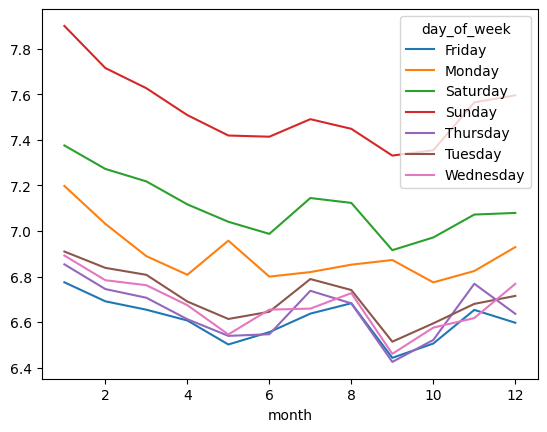

In [23]:
data_df.groupby(["month", "day_of_week"])["average_road_speed"].agg("mean").unstack().plot()

In [24]:
# subset_test = data_test[(data_test["Month"] == 1) & (data_test["Route ID"] == "M4") & (data_test["Day of Week"] == "Monday")]
# subset_test = subset_test[subset_test["Year"] == 2023]
# sorted(subset_test["Stop Order"].unique())

In [25]:
subset = data_df.loc[:,['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 'stop_order', 'timepoint_stop_id', \
       'timepoint_stop_name', 'timepoint_stop_latitude', \
       'timepoint_stop_longitude', 'next_timepoint_stop_id', \
       'next_timepoint_stop_name', 'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude', \
       'road_distance', 'average_travel_time', 'average_road_speed']]
subset = subset.sort_values(['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 'stop_order'])

subset["key"] = subset.loc[:,['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', "direction_id"]].astype(str).agg("-".join, axis = 1)

# creating a data frame so i can merge that with the subset data frame
next_stops = subset.loc[:,["key", "timepoint_stop_name", "stop_order"]]

In [26]:
# merging the two 
merged_data = subset.merge(next_stops,
             left_on = ["key", "next_timepoint_stop_name"],
             right_on = ["key", "timepoint_stop_name"],
             how = "left",
             suffixes = ["", "_next_stop"]
            )

In [27]:
merged_data.drop(["timepoint_stop_name_next_stop"], axis = 1, inplace = True)
merged_data.rename(columns = {"stop_order_next_stop": "next_stop_order"}, inplace = True)
merged_data["missing_segments"] = merged_data.apply(lambda x: list(range(int(x["stop_order"]), int(x["next_stop_order"]) + 1)) if pd.notna(x["next_stop_order"]) and x["next_stop_order"] - x["stop_order"] > 1 else None, axis=1)

In [28]:
merged_data.head(1)

# what i do next
## iterated through all the rows 
### check if there is a list in missing stops
#### if there is -> get each stop from the stop_data df 
#### and find their next one - get their cooridnates and add it to the merged_df at the end
#### assign it the same average speed as the one from the original row

,year,month,day_of_week,hour_of_day,route_id,direction_id,stop_order,timepoint_stop_id,timepoint_stop_name,timepoint_stop_latitude,...,next_timepoint_stop_id,next_timepoint_stop_name,next_timepoint_stop_latitude,next_timepoint_stop_longitude,road_distance,average_travel_time,average_road_speed,key,next_stop_order,missing_segments
0,2023,1,Friday,0,M1,0,6,400001,4 AV/E 10 ST,40.731342,...,405380,MADISON AV/E 28 ST,40.744106,-73.9855,1.031,8.345838,7.41208,2023-1-Friday-0-M1-0,14.0,"[6, 7, 8, 9, 10, 11, 12, 13, 14]"


In [29]:
# new_df = subset.iloc[0:0]

# for _, row in tqdm.tqdm(merged_data.iterrows()):

#     # checking if there are missing stops
#     if row["missing_segments"] is not None:

#         # getting the values to match it with the stops data
#         route_id = row["route_id"]
#         direction = row["direction_id"]

#         i = 0
#         # iterrating over all the missing stops
#         for missing_segment in row["missing_segments"]:
#             row_copy = row.copy()
#             target_row = stop_data.loc[(stop_data["route_id_new"] == route_id) & \
#                                 (stop_data["direction_id"] == direction) & \
#                                 (stop_data["stop_order"] == missing_segment),
#                                 ["stop_id", "stop_name", "latitude", "longitude"]]
#             next_target_row = stop_data.loc[(stop_data["route_id_new"] == route_id) & \
#                                 (stop_data["direction_id"] == direction) & \
#                                 (stop_data["stop_order"] == missing_segment + 1),
#                                 ["stop_id", "stop_name", "latitude", "longitude"]]
            
#             '''
#             'year', 'month', 'day_of_week', 'hour_of_day', 'route_id',
#             'direction_id', 'stop_order', 'timepoint_stop_name',
#             'timepoint_stop_latitude', 'timepoint_stop_longitude',
#             'next_timepoint_stop_id', 'next_timepoint_stop_name',
#             'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude',
#             'road_distance', 'average_travel_time', 'average_road_speed', 'key'
#             '''

#             '''
#             'route_short_name', 'route_long_name', 'route_id', 'direction_id',
#             'direction_name', 'stop_id', 'stop_code', 'stop_name', 'stop_order',
#             'latitude', 'longitude', 'route_id_new', 'stop_order_new'
#             '''
            
#             # assigning the values to the row_copy
#             row_copy["timepoint_stop_id"] = target_row["stop_id"]
#             row_copy["timepoint_stop_name"] = target_row["stop_name"]
#             row_copy["timepoint_stop_latitude"] = target_row["latitude"]
#             row_copy["timepoint_stop_longitude"] = target_row["longitude"]
#             row_copy["next_timepoint_stop_id"] = next_target_row["stop_id"]
#             row_copy["next_timepoint_stop_name"] = next_target_row["stop_name"]
#             row_copy["next_timepoint_stop_latitude"] = next_target_row["latitude"]
#             row_copy["next_timepoint_stop_longitude"] = next_target_row["longitude"]

#             # setting road_distance
#             row_copy["road_distance"] = None
#             row_copy["average_travel_time"] = None

#             new_df = pd.concat([new_df, row_copy])
#     else:
#         new_df = pd.concat([new_df, row])   


In [ ]:
import time
start_time = time.time()

# Separate original rows and rows to expand
original_rows = merged_data[merged_data["missing_segments"].isna()].copy()
rows_to_expand = merged_data[merged_data["missing_segments"].notna()].copy()

# Explode the 'missing_segments' list into multiple rows
expanded_segments = rows_to_expand.explode("missing_segments")

# Prepare keys for merging with stop_data
expanded_segments["target_stop_order"] = expanded_segments["missing_segments"]
expanded_segments["next_stop_order_from_segment"] = expanded_segments["missing_segments"].astype(int) + 1

# Prepare stop_data for merging
stop_data_for_merge = stop_data[['route_id_new', 'direction_id', 'stop_order', 'stop_id', 'stop_name', 'latitude', 'longitude']].copy()
stop_data_for_merge["stop_order"] = stop_data_for_merge["stop_order"].astype(int) # Ensure stop_order is int for merging

# Merge to get the target stop information
merged_expanded = expanded_segments.merge(
    stop_data_for_merge,
    left_on=['route_id', 'direction_id', 'target_stop_order'],
    right_on=['route_id_new', 'direction_id', 'stop_order'],
    how='left',
    suffixes=['', '_target'] # This suffix is not applied to the left df columns
)

# Merge again to get the next stop information
merged_expanded = merged_expanded.merge(
    stop_data_for_merge,
    left_on=['route_id', 'direction_id', 'next_stop_order_from_segment'],
    right_on=['route_id_new', 'direction_id', 'stop_order'],
    how='left',
    suffixes=['', '_next']
)

# --- Debugging: Print columns and check for missing values after merges ---
print("Columns after first merge:", merged_expanded.columns)
print("Missing values in target columns after first merge:")
print(merged_expanded[['stop_id', 'stop_name', 'latitude', 'longitude']].isnull().sum())

print("\nColumns after second merge:", merged_expanded.columns)
print("Missing values in next columns after second merge:")
print(merged_expanded[['stop_id_next', 'stop_name_next', 'latitude_next', 'longitude_next']].isnull().sum())
# --- End Debugging ---


# Select and rename columns to match the original structure
# Adjusted columns based on potential missing columns from left merge
interpolated_rows = merged_expanded[[
    'year', 'month', 'day_of_week', 'hour_of_day', 'route_id',
    'direction_id', 'target_stop_order',
    'stop_id', 'stop_name', 'latitude', 'longitude', # Corrected column names from first merge
    'stop_id_next', 'stop_name_next', 'latitude_next', 'longitude_next',
    'road_distance', 'average_travel_time', 'average_road_speed',
    'key', 'next_stop_order', 'missing_segments'
]].rename(columns={
    'target_stop_order': 'stop_order',
    'stop_id': 'timepoint_stop_id', # Corrected renaming
    'stop_name': 'timepoint_stop_name', # Corrected renaming
    'latitude': 'timepoint_stop_latitude', # Corrected renaming
    'longitude': 'timepoint_stop_longitude', # Corrected renaming
    'stop_id_next': 'next_timepoint_stop_id',
    'stop_name_next': 'next_timepoint_stop_name',
    'latitude_next': 'next_timepoint_stop_latitude',
    'longitude_next': 'next_timepoint_stop_longitude',
})

# Set road_distance and average_travel_time to None for interpolated rows
interpolated_rows['road_distance'] = None
interpolated_rows['average_travel_time'] = None


# Concatenate original rows and interpolated rows
new_df = pd.concat([original_rows, interpolated_rows], ignore_index=True)


new_df.to_csv("extended_list.csv", index=False)

elapsed = time.time() - start_time
print(f"\n✓ Completed in {elapsed:.2f} seconds")
print(f"  - Original rows: {len(original_rows)}")
print(f"  - Interpolated rows: {len(interpolated_rows)}")
print(f"  - Total rows: {len(new_df)}")

Built lookup dict with 2806 stops in 0.05s


1738672it [19:51, 1458.90it/s]




✓ Completed in 1613.86 seconds
  - Original rows: 1615720
  - Expanded rows: 256407774
  - Interpolated segments: 10471222
  - Skipped (missing stops): 48152


In [ ]:
import csv

with open("output.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(rows_list)

In [49]:
rows_list[1]

year                                                         2023
month                                                           1
day_of_week                                                Friday
hour_of_day                                                     0
route_id                                                       M1
direction_id                                                    0
stop_order                                                      6
timepoint_stop_id                                      MTA_400003
timepoint_stop_name                                  4 AV/E 13 ST
timepoint_stop_latitude                                 40.733936
timepoint_stop_longitude                                -73.98972
next_timepoint_stop_id                                 MTA_404120
next_timepoint_stop_name                    UNION SQ EAST/E 15 ST
next_timepoint_stop_latitude                             40.73555
next_timepoint_stop_longitude                          -73.989612
road_dista

In [38]:
new_df.write_csv("Manhattan_Bus_data_extended.csv")

AttributeError: 'Series' object has no attribute 'write_csv'

In [31]:
len(subset)

1615720

In [32]:
stop_data.loc[(stop_data["route_id_new"] == "M1"),["latitude"]]

,latitude
1759,40.720678
1760,40.722433
1761,40.725154
1762,40.728066
1763,40.729751
...,...
1887,40.725107
1888,40.724012
1889,40.722843
1890,40.730069


In [33]:
# stops = data_df.loc[:, ['year', 'month', 'day_of_week', 'hour_of_day', "route_id", "stop_order", "timepoint_stop_id", "direction_id"]].copy()

# # Rename columns so we're matching next_stop info
# # Keep direction_id as-is (int) so we merge on the same-typed column
# stops_renamed = stops.rename(columns={
#     'stop_order': 'next_stop_order'
# })

# # Merge: find the stop_order for each row's next_timepoint_stop_id
# data_df = data_df.merge(
#     stops_renamed,
#     left_on=['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 'next_timepoint_stop_id'],
#     right_on=['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 'timepoint_stop_id'],
#     how='left',
#     suffixes=["", "_stop"]
# )


In [34]:
stop_data.columns

Index(['route_short_name', 'route_long_name', 'route_id', 'direction_id',
       'direction_name', 'stop_id', 'stop_code', 'stop_name', 'stop_order',
       'latitude', 'longitude', 'route_id_new', 'stop_order_new'],
      dtype='object')

In [35]:
subset.columns

Index(['year', 'month', 'day_of_week', 'hour_of_day', 'route_id',
       'direction_id', 'stop_order', 'timepoint_stop_id',
       'timepoint_stop_name', 'timepoint_stop_latitude',
       'timepoint_stop_longitude', 'next_timepoint_stop_id',
       'next_timepoint_stop_name', 'next_timepoint_stop_latitude',
       'next_timepoint_stop_longitude', 'road_distance', 'average_travel_time',
       'average_road_speed', 'key'],
      dtype='object')

In [36]:
data_df.columns

Index(['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction',
       'borough', 'route_type', 'stop_order', 'timepoint_stop_id',
       'timepoint_stop_name', 'timepoint_stop_latitude',
       'timepoint_stop_longitude', 'next_timepoint_stop_id',
       'next_timepoint_stop_name', 'next_timepoint_stop_latitude',
       'next_timepoint_stop_longitude', 'road_distance', 'average_travel_time',
       'average_road_speed', 'bus_trip_count', 'timepoint_stop_georeference',
       'next_timepoint_stop_georeference', 'zip_code', 'direction_id'],
      dtype='object')